In [25]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Path containing participant files

data_dir = Path(
    "/Users/sm6511/Desktop/Prediction-Accomodation-Exp/data/Study6.0/raw"
)

# Columns to extract

rating_cols = [
    "obvious_slider.response",
    "good_slider.response"
]

keep_cols = [
    "explanationCategory",
    *rating_cols
]

# Load all participants

all_participants = []

for file_path in data_dir.glob("*.csv"):

    try:
        df = pd.read_csv(file_path)

        # Participant ID = portion of filename before first "_"
        # e.g. 137237_pa6fresh_2026... -> 137237
        participant = file_path.name.split("_")[0]

        # Keep only rows corresponding to an explanation category
        df_ratings = (
            df.loc[
                df["explanationCategory"].notna(),
                keep_cols
            ]
            .copy()
        )

        # Add participant ID
        df_ratings.insert(0, "participant", participant)

        all_participants.append(df_ratings)

        print(
            f"{participant}: "
            f"{len(df_ratings)} explanation categories"
        )

    except Exception as e:
        print(f"ERROR: {file_path.name}: {e}")


# Combine participants into one dataframe

df_ratings = pd.concat(
    all_participants,
    ignore_index=True
)

print(df_ratings.head())
print(df_ratings.shape)

df_ratings = df_ratings.rename(columns={
    "obvious_slider.response": "obvious",
    "good_slider.response": "good"
})

310688: 8 explanation categories
356916: 8 explanation categories
788793: 8 explanation categories
615902: 8 explanation categories
817664: 8 explanation categories
031362: 8 explanation categories
662588: 8 explanation categories
859284: 8 explanation categories
063752: 8 explanation categories
340858: 8 explanation categories
778390: 8 explanation categories
218395: 8 explanation categories
126419: 8 explanation categories
603080: 8 explanation categories
654465: 8 explanation categories
423787: 8 explanation categories
987615: 8 explanation categories
792520: 8 explanation categories
438449: 8 explanation categories
343823: 8 explanation categories
156455: 8 explanation categories
996981: 8 explanation categories
328271: 8 explanation categories
788769: 8 explanation categories
331613: 8 explanation categories
131345: 8 explanation categories
161582: 8 explanation categories
113729: 8 explanation categories
044153: 8 explanation categories
539582: 8 explanation categories
380121: 8 

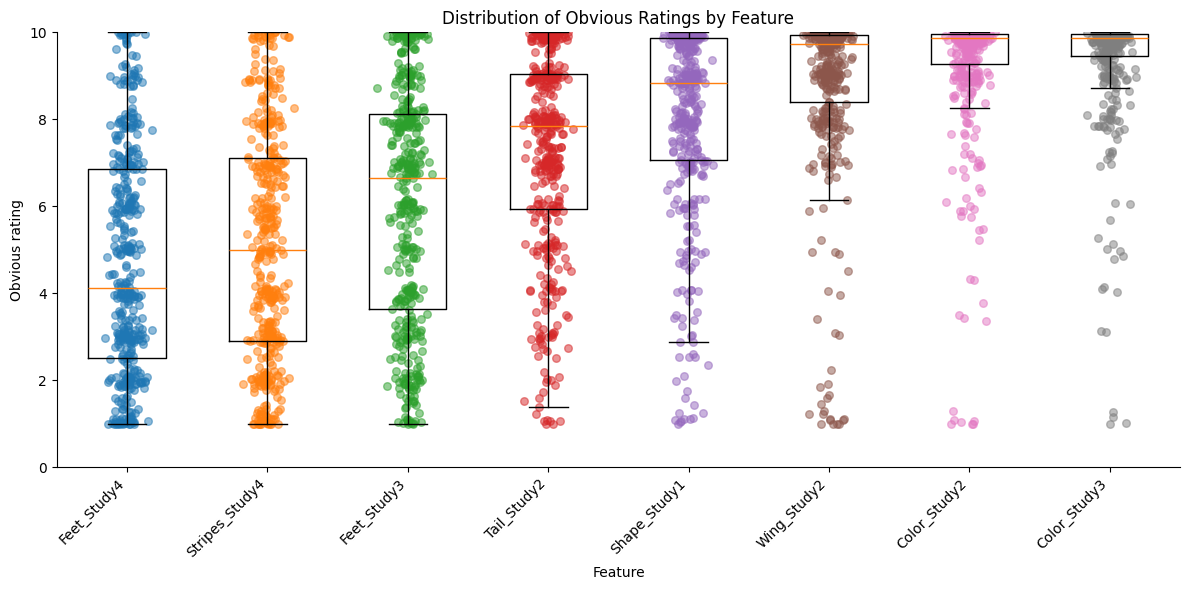

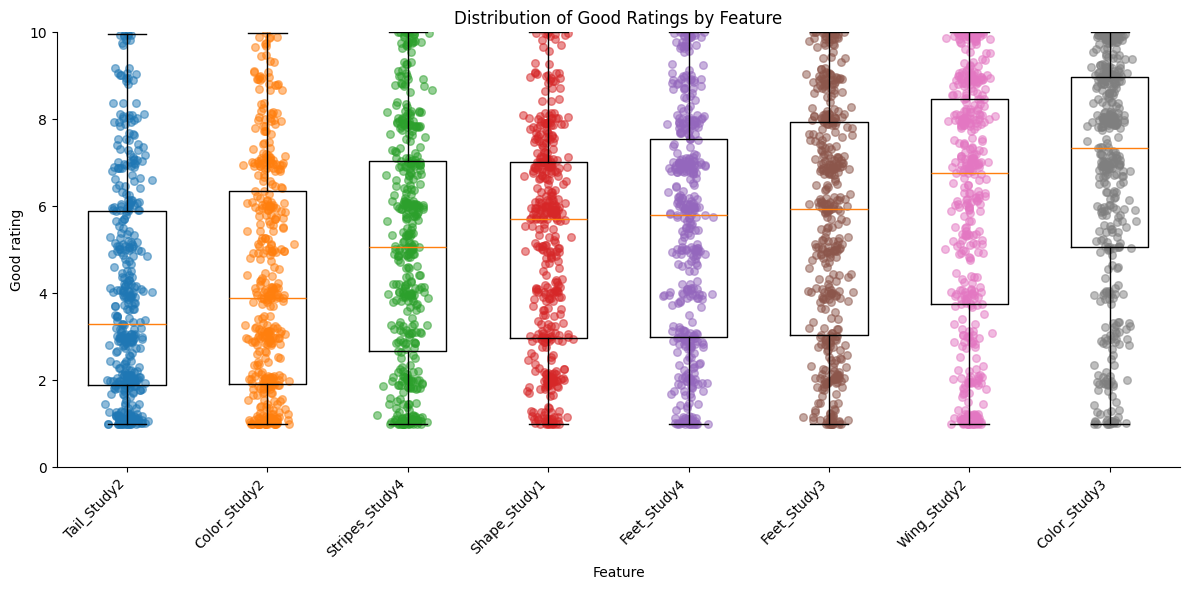

In [28]:
df_plot = df_ratings.copy()

rating_cols = [
    "obvious",
    "good"
]

##Plot each rating

for rating in rating_cols:

    fig, ax = plt.subplots(figsize=(12, 6))

    # Get order based on mean rating
    features = (
    df_plot
    .groupby("explanationCategory")[rating]
    .mean()
    .sort_values()
    .index
)
    
    data = [
        df_plot.loc[
            df_plot["explanationCategory"] == feature,
            rating
        ].dropna().values
        for feature in features
    ]

    # Boxplots
    ax.boxplot(
        data,
        positions=np.arange(len(features)),
        widths=0.55,
        showfliers=False
    )

    # Individual participant observations (jittered)
    rng = np.random.default_rng(42)

    for i, values in enumerate(data):

        jitter = rng.normal(
            loc=0,
            scale=0.06,
            size=len(values)
        )

        ax.scatter(
            i + jitter,
            values,
            alpha=0.5,
            s=30
        )

    # Formatting

    ax.set_xticks(np.arange(len(features)))
    ax.set_xticklabels(
        features,
        rotation=45,
        ha="right"
    )

    ax.set_xlabel("Feature")
    ax.set_ylabel(f"{rating.capitalize()} rating")
    ax.set_title(
        f"Distribution of {rating.capitalize()} Ratings by Feature"
    )

    ax.set_ylim(0, 10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()


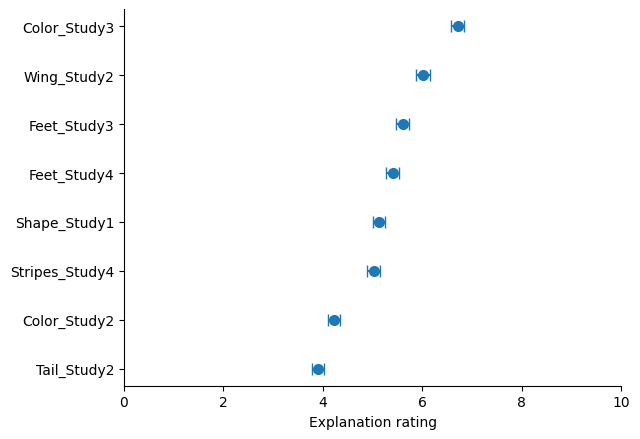

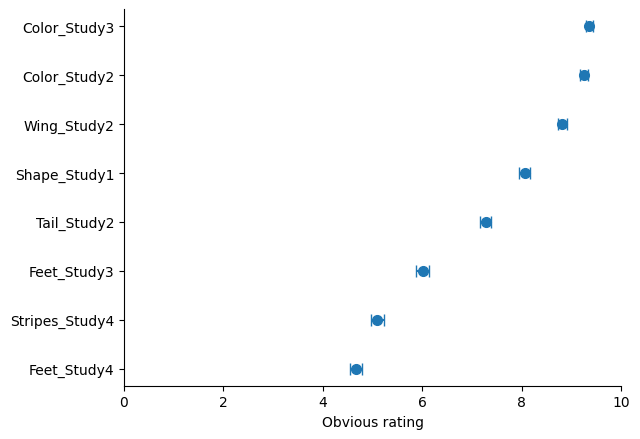

In [29]:
# Two plots:
# 1. Good ratings
# 2. Salient ratings

rating_pairs = [
    ("good", "Explanation rating"),
    ("obvious", "Obvious rating")
]

for rating, xlabel in rating_pairs:

    # Order features by mean rating
    feature_order = (
        df_plot
        .groupby("explanationCategory")[rating]
        .mean()
        .sort_values()
        .index
    )

    # Summary statistics
    summary = (
        df_plot
        .groupby("explanationCategory")[rating]
        .agg(["mean", "sem"])
        .loc[feature_order]
    )

    fig, ax = plt.subplots(figsize=(6.5, 4.5))

    y = np.arange(len(feature_order))

    ax.errorbar(
        summary["mean"],
        y,
        xerr=summary["sem"],
        fmt="o",
        markersize=7,
        capsize=4,
        linewidth=1.5
    )

    ax.set_yticks(y)
    ax.set_yticklabels(feature_order)

    ax.set_xlabel(xlabel)
    ax.set_xlim(0, 10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

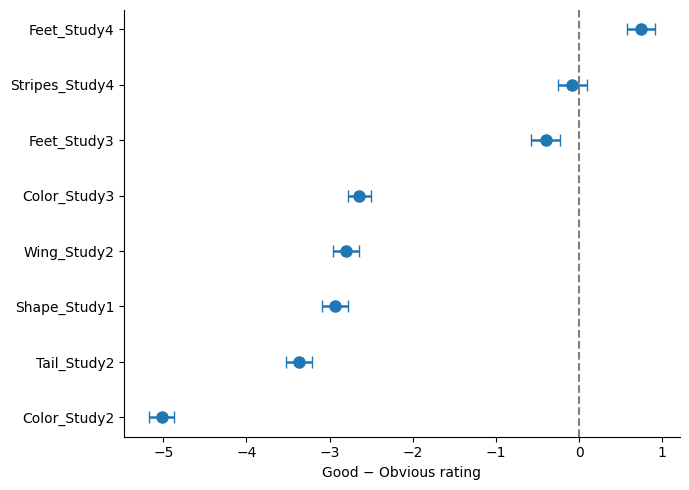

In [30]:
import matplotlib.pyplot as plt
import numpy as np

#Create good minus obvious column
df_plot = df_ratings.copy()
df_plot["good_minus_obvious"] = (
    df_plot["good"] - df_plot["obvious"]
)

# Order features by mean difference
feature_order = (
    df_plot
    .groupby("explanationCategory")["good_minus_obvious"]
    .mean()
    .sort_values()
    .index
)

# Summary stats
summary = (
    df_plot
    .groupby("explanationCategory")["good_minus_obvious"]
    .agg(["mean", "sem"])
    .loc[feature_order]
)

# Plot

fig, ax = plt.subplots(figsize=(7, 5))

y = np.arange(len(feature_order))

ax.errorbar(
    summary["mean"],
    y,
    xerr=summary["sem"],
    fmt="o",
    markersize=8,
    capsize=4,
    linewidth=1.8
)

# Reference line: Good = Obvious
ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5,
    color="gray"
)

ax.set_yticks(y)
ax.set_yticklabels(feature_order)

ax.set_xlabel("Good − Obvious rating")
ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [31]:
df_plot.to_csv(
    "/Users/sm6511/Desktop/Prediction-Accomodation-Exp/data/Combined/Study6.0Ratings.csv",
    index=False
)